<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/03_Dimensionality_Reduction_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dimensionality Reduction Techniques**
This notebook covers The Dimensionality Reduction Techniques:

1. Introduction to Dimensionality Reduction
2. Transforming Datasets with PCA
3. Maximizing Class Separability with LDA
4. t-SNE and Data Visualization
5. Guidelines for selecting dimensionality reduction techniques
6. Impact on Model Performance

# **1. Introduction to Dimensionality Reduction**

Dimensionality reduction is a fundamental task in developing machine learning pipelines, functioning on par with data preprocessing. The core objective involves reducing the number of features within a dataset while deliberately retaining as much relevant information as possible.

## **1.1. Why Dimensionality Reduction is Essential**

Rather than simply feeding a model with maximum data, it is crucial to distill data into a manageable representation to avoid introducing irrelevant "garbage" into the model. The text outlines several essential reasons for this approach:

- Simplifying data: Reducing features makes high-dimensional datasets easier to interpret, analyze, and use for decision-making.

- Reducing computational costs: Fewer features decrease the computational resources required for training, enabling faster training times and the ability to handle larger datasets.

- Improving model performance: High-dimensional data risks overfitting, where a model learns noise; dimensionality reduction eliminates irrelevant features so the model generalizes better on unseen data.

- Enhancing visualization: It allows for the projection of complex datasets into two or three dimensions, making visualization feasible.

## **1.2. Theoretical Foundations of Dimensionality Reduction**

The techniques are broadly categorized into two main types: feature selection and feature extraction.



### **1.2.1. Feature Selection**

Feature selection involves choosing a relevant subset of features from the original dataset without transforming the data itself.


- Filter methods: These methods assess feature relevance based on statistical properties, such as correlation with a target variable.

- Wrapper methods: These methods evaluate feature subsets by training a model and assessing its performance.

- Embedded methods: These methods perform selection directly as part of the model training process, such as Lasso regression.

### **1.2.2. Feature Extraction**

Feature extraction differs by transforming the original features into a entirely new space with fewer dimensions while keeping essential information intact. Notable techniques include:
- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)
- t-Distributed Stochastic Neighbor Embedding (t-SNE).

# **2. Transforming Datasets with PCA**

Principal Component Analysis (PCA) simplifies datasets by transforming them into a new coordinate system, where the initial dimensions (principal components) capture the greatest variance.

## **Getting Ready**

Before applying PCA, it is standard practice to load the dataset and ensure it is standardized, which includes separating the target variable.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import warnings

np.random.seed(2024)
warnings.simplefilter(action='ignore', category=FutureWarning)

wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target

print(f"Dataset shape: {df_wine.shape}")
print(f"Classes: {wine.target_names}")
print(f"Samples per class: {np.bincount(target_wine)}")
print(f"\nFirst 10 rows:")
display(df_wine.head(10))

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Samples per class: [59 71 48]

First 10 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


## **How to do it…**

The implementation utilizes scikit-learn's Pipeline to string together standard scaling and the PCA transformation.

Original shape: (178, 13)
Transformed shape: (178, 2)
Dimensionality reduction: 13 features → 2 components


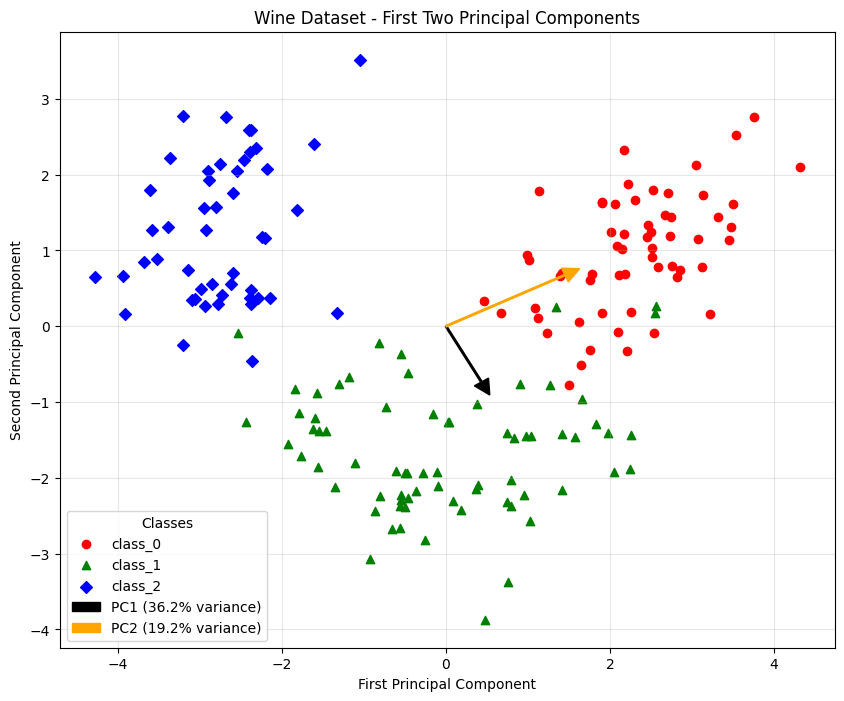

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Create a pipeline: scale first, then apply PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),    # Always scale before PCA
    ('pca', PCA(n_components=2))     # Reduce to 2 dimensions
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_wine)

print(f"Original shape: {df_wine.shape}")
print(f"Transformed shape: {X_pca.shape}")
print(f"Dimensionality reduction: {df_wine.shape[1]} features → {X_pca.shape[1]} components")
# Visualize the PCA-transformed data with component vectors
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot scatter points by class
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(
        X_pca[target_wine == i, 0],
        X_pca[target_wine == i, 1],
        c=color, marker=shape,
        label=wine.target_names[i]
    )

# Get PCA components and plot as direction vectors
pca = pca_pipeline.named_steps['pca']
origin = np.zeros(2)
arrow_colors = ['black', 'orange']

# Scale components for visibility
scaling = 3
for i, (component, ratio) in enumerate(zip(
    pca.components_, pca.explained_variance_ratio_)
):
    plt.arrow(
        origin[0], origin[1],
        component[0] * scaling,
        component[1] * scaling,
        color=arrow_colors[i],
        width=0.02,
        head_width=0.2, head_length=0.2,
        label=f'PC{i+1} ({ratio:.1%} variance)'
    )

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

## **How it works…**

PCA identifies the directions of maximum variance through linear, orthogonal combinations of original features. The process requires standardizing the data to a $mean=0$ and variance of 1, computing a covariance matrix, and then calculating eigenvalues (variance amount) and eigenvectors (component direction). Finally, the data is projected onto the selected principal components.

PC1 explained variance: 0.3620 (36.20%)
PC2 explained variance: 0.1921 (19.21%)
Cumulative explained variance: 0.5541 (55.41%)


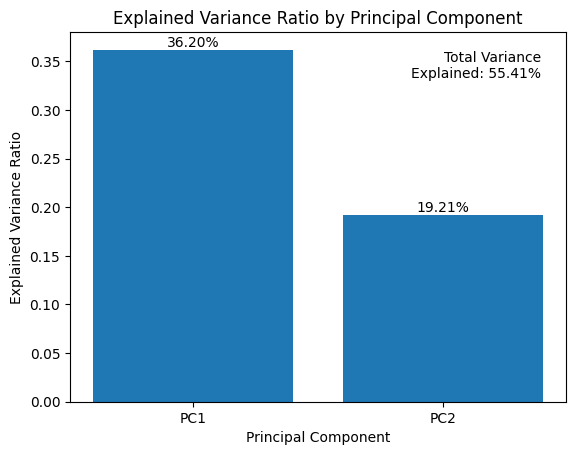

In [3]:
# Explained variance ratio
pca = pca_pipeline.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance_ratio)

print(f"PC1 explained variance: {explained_variance_ratio[0]:.4f} ({explained_variance_ratio[0]:.2%})")
print(f"PC2 explained variance: {explained_variance_ratio[1]:.4f} ({explained_variance_ratio[1]:.2%})")
print(f"Cumulative explained variance: {cumulative_variance:.4f} ({cumulative_variance:.2%})")

# Visualize
fig, ax = plt.subplots()
x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
bars = ax.bar(x, y)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2%}',
            ha='center', va='bottom')

ax.text(0.95, 0.95, f'Total Variance\nExplained: {cumulative_variance:.2%}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

# **3. Maximizing Class Separability with LDA**

Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique tailored for classification tasks.

## **Getting Ready**

LDA utilizes the same separated feature and target arrays from the dataset previously loaded.

## **How to do it…**

Like PCA, LDA is implemented cleanly using a pipeline that includes a scaling step.

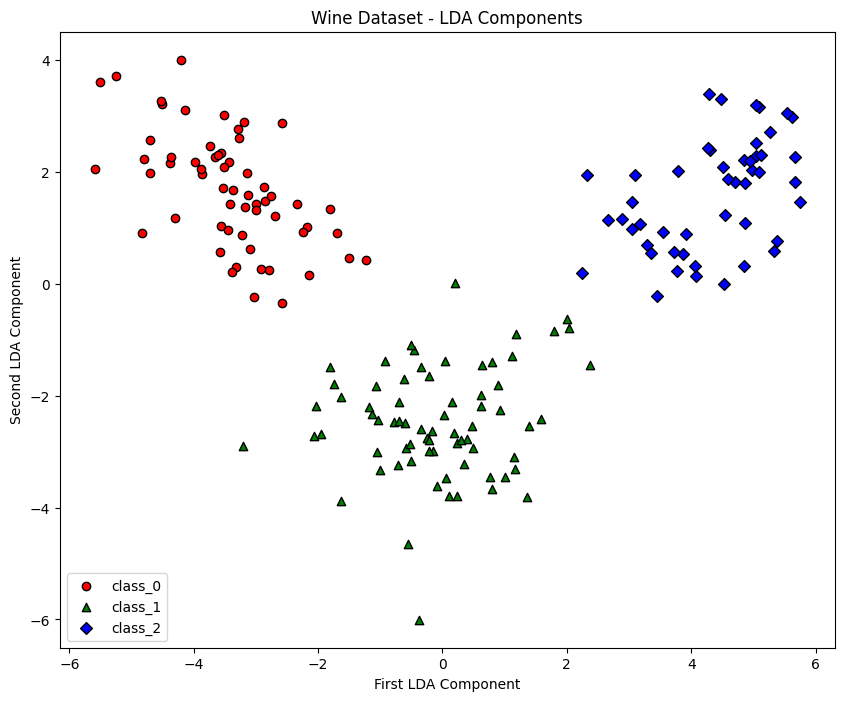

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_wine, y_wine = wine.data, wine.target

lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))
    # min(n_features, n_classes - 1) for wine dataset is 2
])

X_lda_wine = lda_pipeline_wine.fit_transform(
    X_wine, y_wine
)

plt.figure(figsize=(10, 8))

shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(
        X_lda_wine[mask, 0], X_lda_wine[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )
plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

## **How it works…**

LDA aims to find a linear combination of features that maximizes the distance between different classes while minimizing the variance within each specific class. It operates under the assumption that the data for each class follows a Gaussian distribution with a common covariance matrix.

# **4. Differences between PCA and LDA**

- Supervised vs. Unsupervised: PCA is unsupervised and ignores class labels to maximize variance, whereas LDA is supervised and uses labeled data to maximize class separability.

- Output: PCA generates orthogonal principal components, while LDA produces specifically designed linear discriminants.

- Use Cases: PCA is generally for exploratory data analysis, and LDA is primarily for classification tasks.

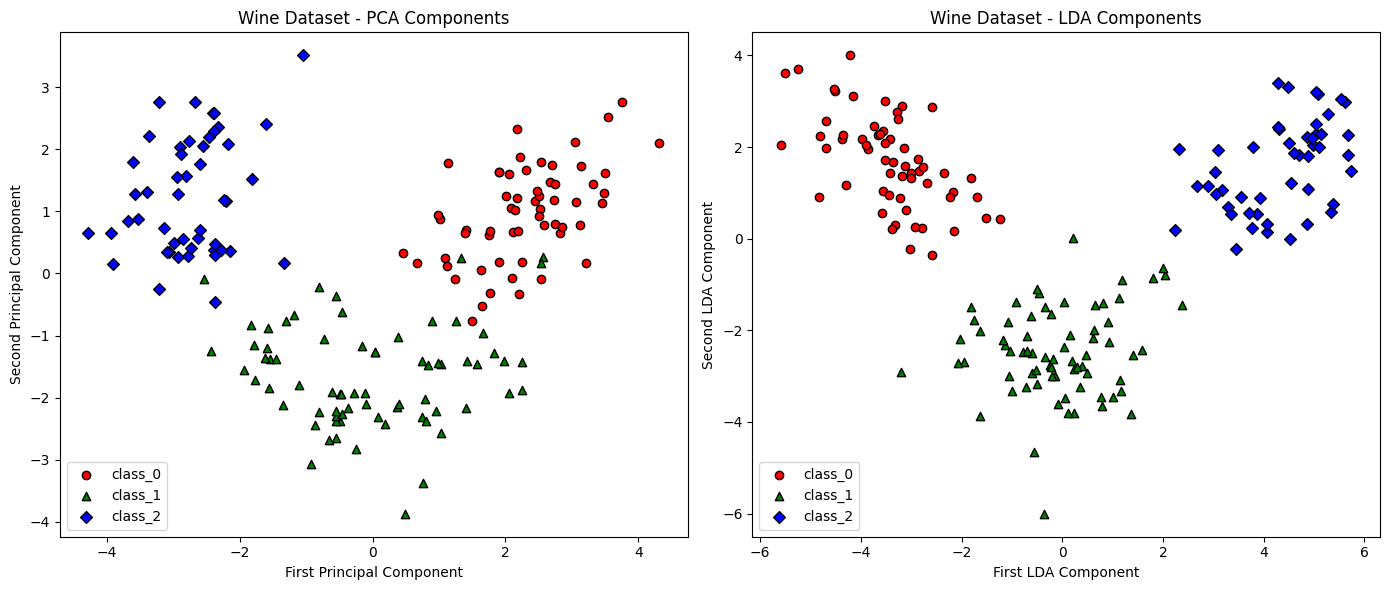

In [5]:
plt.figure(figsize=(14, 6))
plt.subplot(121)
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()
plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(
        X_lda_wine[mask, 0], X_lda_wine[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )
plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.tight_layout()
plt.show()

# **5. t-SNE and Data Visualization**

t-Distributed Stochastic Neighbor Embedding (t-SNE) maps high-dimensional data into a two or three-dimensional space to reveal underlying clusters and complex relationships.

## **Getting Ready**

To observe t-SNE effectively, a more complex dataset, such as the MNIST handwritten digits dataset, is utilized.

In [6]:
from sklearn.datasets import load_digits
digits = load_digits()

## **How to do it…**

The workflow remains consistent, utilizing a pipeline to scale and apply the TSNE class.

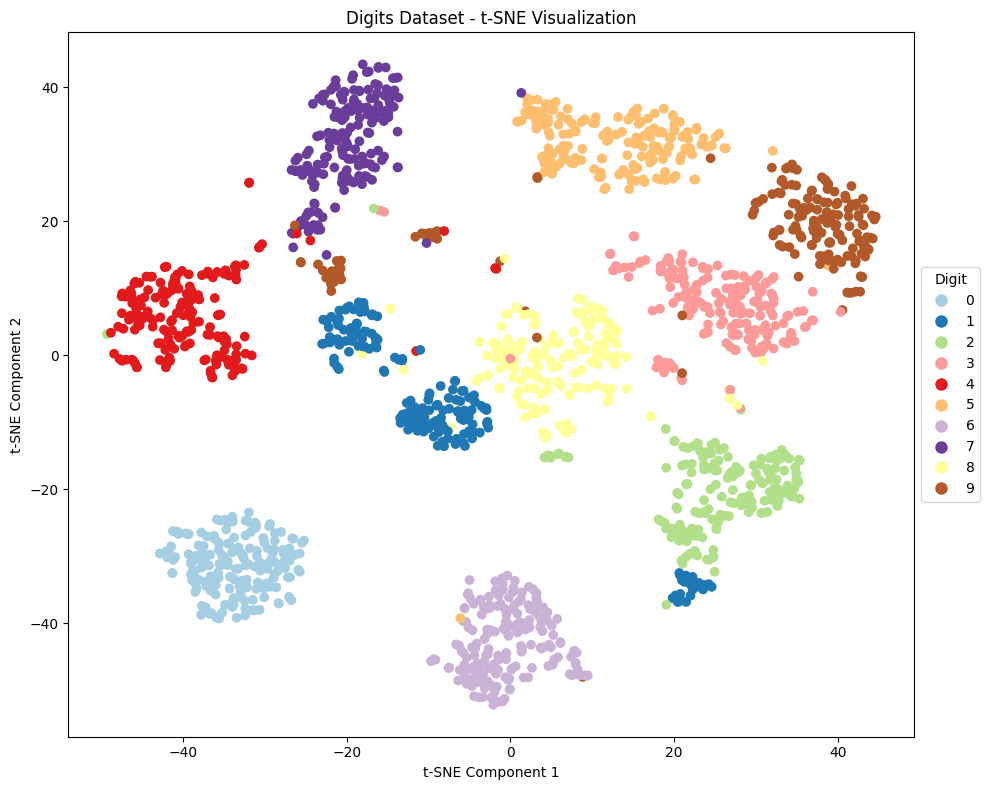

In [7]:
from sklearn.manifold import TSNE

tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

X_tsne = tsne_pipeline.fit_transform(digits.data)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=digits.target, cmap='Paired',
    label=digits.target
)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

legend_elements = [
    plt.Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=plt.cm.Paired(i/9),
        label=str(i), markersize=10
    )
    for i in range(10)
]
plt.legend(
    handles=legend_elements,
    title='Digit', loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

## **How it works…**

As a non-linear technique, t-SNE calculates pairwise similarities between high-dimensional points, converting Euclidean distances into conditional probabilities. It then forms a low-dimensional map that preserves these similarities, naturally grouping similar data points and spacing out dissimilar ones to reveal clusters.

# **6. Guidelines for selecting dimensionality reduction techniques**

Choosing the correct method is dictated by the data and analytical goals.

- Supervised vs. unsupervised: Use LDA for labeled data to separate classes, use PCA for unlabeled variance capture, and t-SNE strictly for visualization.

- Efficiency: PCA handles large datasets efficiently, LDA may struggle with high dimensions or many classes due to covariance computations, and t-SNE is highly computationally intensive due to iterative optimization.

- Interpretability: PCA components can be difficult to interpret, LDA discriminants are slightly easier for class separation, and t-SNE offers visual results but lacks direct feature interpretation.

## **6.1. Practical steps for selection**

Here’s how to select the right dimensionality reduction technique for your specific dataset and problem:
- Outline the primary objective: improving performance or visualizing data.

- Understand if the data is labeled and assess its dimensionality.

- Assess available computational resources.

- Apply multiple techniques if unsure, then evaluate based on model metrics or visualization clarity.**bold text**

# **7. Impact on Model Performance**
While dimensionality reduction can streamline training, it forces researchers to navigate critical trade-offs that impact accuracy.

## **7.1. Understanding the trade-offs**

When applying dimensionality reduction techniques, several trade-offs must be considered:
- Complexity vs. interpretability: Fewer features yield simpler models, but discarding dimensions may result in a loss of critical information.

- Training time vs. accuracy: Reduced dimensions speed up computational time, but discarding important features can cause a sacrifice in predictive accuracy.

- Overfitting vs. generalization: Eliminating noise helps the model generalize to unseen data, but removing too many dimensions risks underfitting, where the model becomes overly simplistic.

# **Practical exercises in dimensionality reduction**

To reinforce these concepts, the text suggests applying these techniques to subsequent modeling workflows. For example, one can test the impact of PCA paired with a logistic regression model on an Iris dataset, or utilize t-SNE paired with K-means clustering to visualize the complex MNIST dataset.